# Used Car Price Prediction

## Problem Statement

The goal of this project is to analyze used car data and build a machine learning model that predicts the expected selling price of a used car based on its specifications and usage information.

## Problem Framing

This is a supervised machine learning regression problem because the target variable, car price, is numerical.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding

In [5]:
df = pd.read_csv("data/used_cars-selected-columns.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


In [6]:
df.shape

(4009, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  price         4009 non-null   str  
dtypes: int64(1), str(10)
memory usage: 344.7 KB


In [8]:
df.describe(include="all")

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
price             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
price           1569
dtype: int64

In [12]:
df["price"].head(10)

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
5    $14,798
6    $31,000
7     $7,300
8    $41,927
9    $69,950
Name: price, dtype: str

In [13]:
df["milage"].head(10)

0     51,000 mi.
1     34,742 mi.
2     22,372 mi.
3     88,900 mi.
4      9,835 mi.
5    136,397 mi.
6     84,000 mi.
7    242,000 mi.
8     23,436 mi.
9     34,000 mi.
Name: milage, dtype: str

In [14]:
df["engine"].head(10)

0    300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...
1                                 3.8L V6 24V GDI DOHC
2                                       3.5 Liter DOHC
3    354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...
4                           2.0L I4 16V GDI DOHC Turbo
5                                            2.4 Liter
6         292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel
7         282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel
8        311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
9          534.0HP Electric Motor Electric Fuel System
Name: engine, dtype: str

In [15]:
df["accident"].value_counts(dropna=False)

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [16]:
df["fuel_type"].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

## Data Cleaning

In [17]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [18]:
df["price"].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [19]:
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

In [20]:
df.rename(columns={"milage": "mileage"}, inplace=True)

In [21]:
df["mileage"].head()

0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: mileage, dtype: float64

In [22]:
df["fuel_type"] = df["fuel_type"].replace(
    ["–", "not supported"],
    "Unknown"
)

df["fuel_type"] = df["fuel_type"].fillna("Unknown")

In [23]:
df["fuel_type"].value_counts()

fuel_type
Gasoline          3309
Unknown            217
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [24]:
df["accident"] = df["accident"].fillna("Unknown")

In [25]:
df["accident"].value_counts()

accident
None reported                             2910
At least 1 accident or damage reported     986
Unknown                                    113
Name: count, dtype: int64

In [26]:
df.isnull().sum()

brand           0
model           0
model_year      0
mileage         0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
price           0
dtype: int64

## Feature Engineering from Engine Column

In [27]:
df["horsepower"] = df["engine"].str.extract(r'(\d+\.?\d*)HP')[0]
df["engine_size"] = df["engine"].str.extract(r'(\d+\.?\d*)L')[0]

In [28]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["engine_size"] = pd.to_numeric(df["engine_size"], errors="coerce")

In [29]:
df[["engine", "horsepower", "engine_size"]].head(10)

,engine,horsepower,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0,3.7
1,3.8L V6 24V GDI DOHC,NaN,3.8
2,3.5 Liter DOHC,NaN,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0,3.5
4,2.0L I4 16V GDI DOHC Turbo,NaN,2.0
5,2.4 Liter,NaN,NaN
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,292.0,2.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,282.0,4.4
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,311.0,3.5
9,534.0HP Electric Motor Electric Fuel System,534.0,NaN


In [30]:
df["engine_size"] = df["engine"].str.extract(
    r'(\d+\.?\d*)\s*(?:L|Liter)',
    expand=False
)

df["engine_size"] = pd.to_numeric(
    df["engine_size"],
    errors="coerce"
)

In [31]:
df[["horsepower", "engine_size"]].isnull().sum()

horsepower     808
engine_size    217
dtype: int64

In [32]:
df["car_age"] = 2026 - df["model_year"]

In [33]:
df[["model_year", "car_age"]].head()

,model_year,car_age
0,2013,13
1,2021,5
2,2022,4
3,2015,11
4,2021,5


In [34]:
df["engine_size"] = df["engine"].str.extract(
    r'(\d+\.?\d*)\s*(?:L|Liter)',
    expand=False
)

df["engine_size"] = pd.to_numeric(
    df["engine_size"],
    errors="coerce"
)

In [35]:
df[["engine", "engine_size"]].head(10)

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,3.5
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0
5,2.4 Liter,2.4
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,4.4
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,3.5
9,534.0HP Electric Motor Electric Fuel System,NaN


In [36]:
df["engine_size"].isnull().sum()

np.int64(217)

In [37]:
df["horsepower"].median()

np.float64(310.0)

In [38]:
df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].median()
)

In [39]:
df["engine_size"] = df["engine_size"].fillna(
    df["engine_size"].median()
)

In [40]:
df[["horsepower", "engine_size"]].isnull().sum()

horsepower     0
engine_size    0
dtype: int64

In [41]:
reference_year = df["model_year"].max()

df["car_age"] = reference_year - df["model_year"]

In [42]:
df[["model_year", "car_age"]].head()

,model_year,car_age
0,2013,11
1,2021,3
2,2022,2
3,2015,9
4,2021,3


## Exploratory Data Analysis

In [43]:
df["price"].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

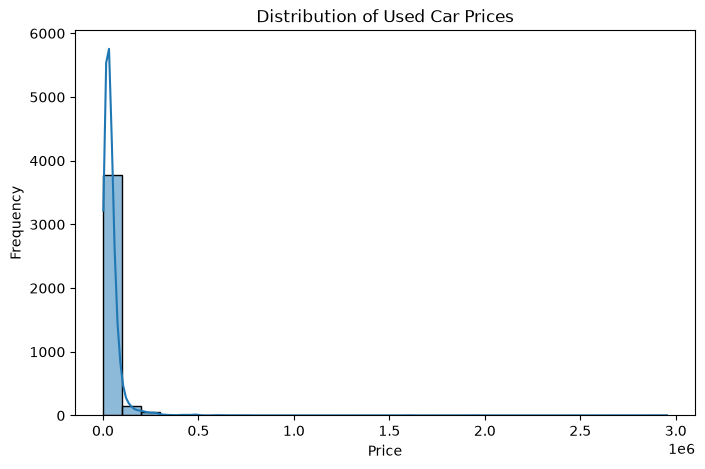

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

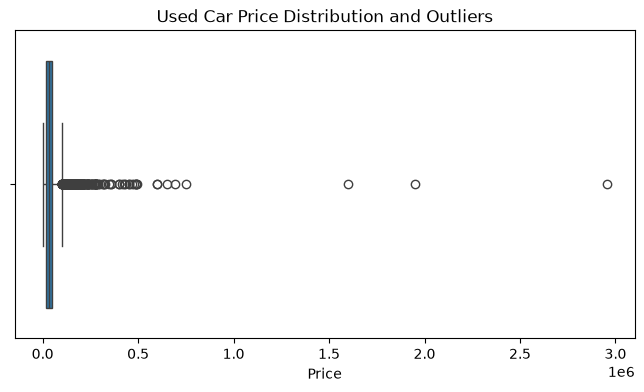

In [45]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price"])
plt.title("Used Car Price Distribution and Outliers")
plt.xlabel("Price")
plt.show()

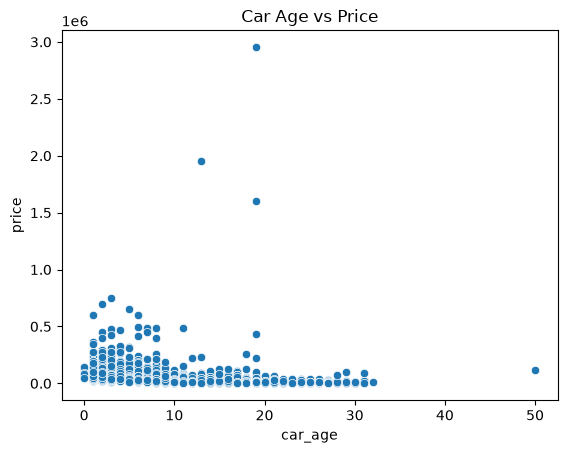

In [46]:
sns.scatterplot(data=df, x="car_age", y="price")
plt.title("Car Age vs Price")
plt.show()

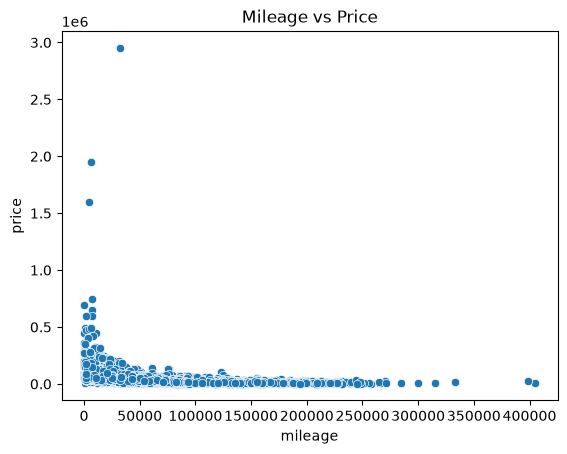

In [47]:
sns.scatterplot(data=df, x="mileage", y="price")
plt.title("Mileage vs Price")
plt.show()

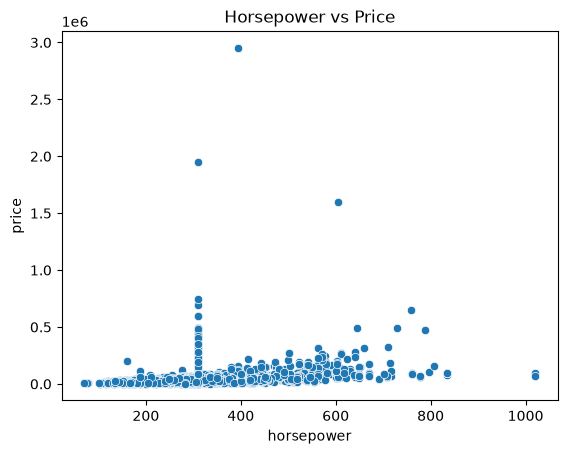

In [48]:
sns.scatterplot(data=df, x="horsepower", y="price")
plt.title("Horsepower vs Price")
plt.show()

In [49]:
df[
    ["brand", "model", "model_year", "mileage",
     "horsepower", "engine_size", "price"]
].sort_values(
    "price",
    ascending=False
).head(20)

,brand,model,model_year,mileage,horsepower,engine_size,price
693,Maserati,Quattroporte Base,2005,32000.0,394.0,4.2,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,310.0,8.0,1950995.0
3046,Porsche,Carrera GT Base,2005,4400.0,605.0,5.7,1599000.0
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,310.0,6.5,749950.0
624,Rolls-Royce,Cullinan,2022,398.0,310.0,6.7,695000.0
979,Lamborghini,Aventador SVJ Base,2019,6929.0,759.0,6.5,649999.0
1615,Rolls-Royce,Phantom,2023,1560.0,310.0,3.5,599995.0
1508,Rolls-Royce,Phantom,2018,7585.0,310.0,6.8,599000.0
3655,Lamborghini,Aventador S Base,2018,5858.0,729.0,6.5,491836.0
1061,Dodge,Viper GTC,2017,1389.0,645.0,8.4,489995.0


In [50]:
df["price"].quantile([0.90, 0.95, 0.99])

0.90     79999.00
0.95    111600.00
0.99    272713.28
Name: price, dtype: float64

In [51]:
(df["price"] > 100000).sum()

np.int64(234)

In [52]:
df = df.drop(index=693)

In [53]:
df.reset_index(drop=True, inplace=True)

In [54]:
df["price"].describe()

count    4.008000e+03
mean     4.382726e+04
std      6.390414e+04
min      2.000000e+03
25%      1.717500e+04
50%      3.100000e+04
75%      4.996000e+04
max      1.950995e+06
Name: price, dtype: float64

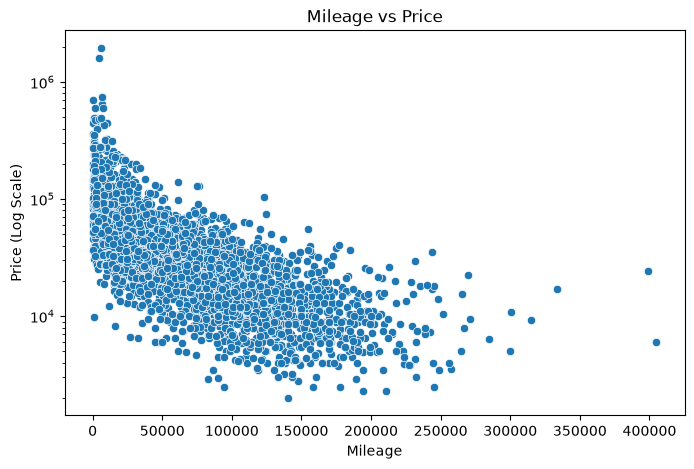

In [55]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="mileage", y="price")
plt.yscale("log")
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price (Log Scale)")
plt.show()

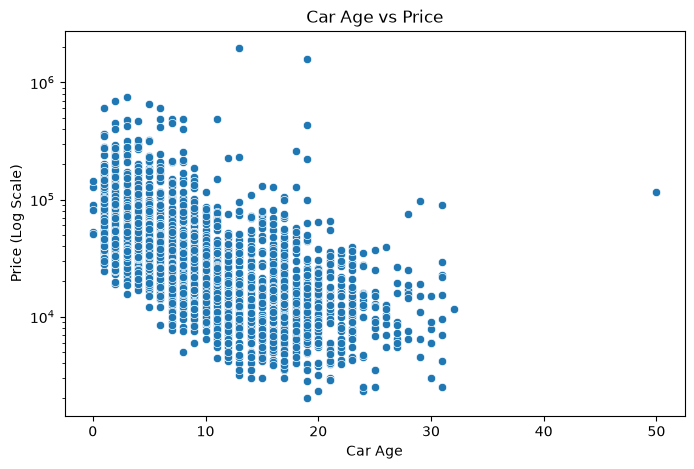

In [56]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="price")
plt.yscale("log")
plt.title("Car Age vs Price")
plt.xlabel("Car Age")
plt.ylabel("Price (Log Scale)")
plt.show()


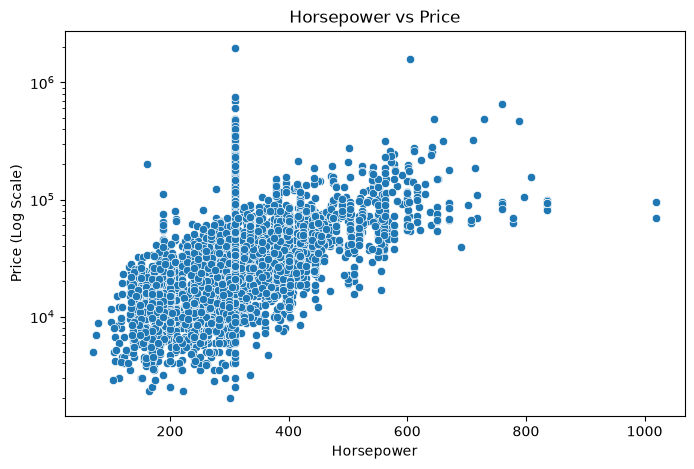

In [57]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="horsepower", y="price")
plt.yscale("log")
plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price (Log Scale)")
plt.show()

In [58]:
numeric_cols = [
    "model_year",
    "mileage",
    "horsepower",
    "engine_size",
    "car_age",
    "price"
]

df[numeric_cols].corr()

,model_year,mileage,horsepower,engine_size,car_age,price
model_year,1.000000,-0.618248,0.239922,-0.111385,-1.000000,0.265423
mileage,-0.618248,1.000000,-0.293658,0.073396,0.618248,-0.369274
horsepower,0.239922,-0.293658,1.000000,0.518699,-0.239922,0.322573
engine_size,-0.111385,0.073396,0.518699,1.000000,0.111385,0.211611
car_age,-1.000000,0.618248,-0.239922,0.111385,1.000000,-0.265423
price,0.265423,-0.369274,0.322573,0.211611,-0.265423,1.000000


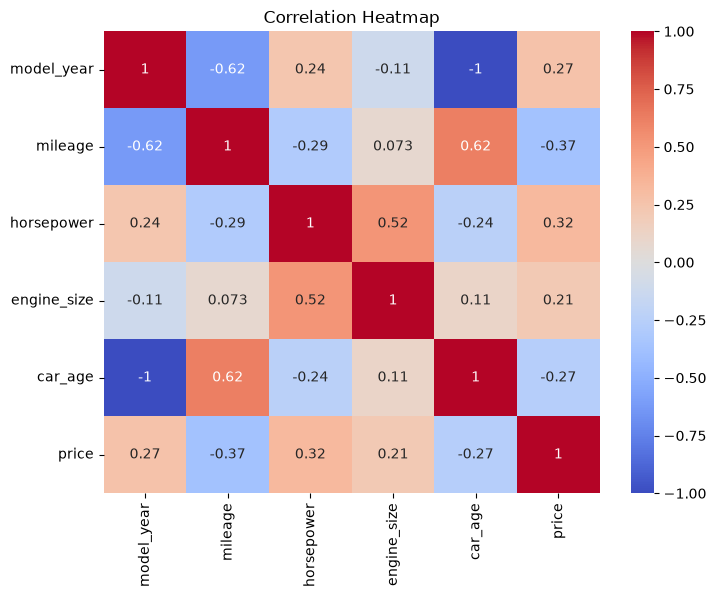

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### Numerical EDA Insights

- Mileage shows the strongest negative relationship with price. Cars with higher mileage generally have lower selling prices.
- Horsepower shows a positive relationship with price, suggesting more powerful cars tend to be more expensive.
- Newer vehicles generally have higher prices, while car age is negatively related to price.
- Engine size has a weaker positive relationship with price compared with horsepower.
- Model year and car age are perfectly negatively correlated because car age was directly derived from model year. Therefore, only one of these features should be used during model training.
- None of the individual numerical features has an extremely strong correlation with price, suggesting that used-car prices depend on a combination of numerical and categorical characteristics.

## Categorical EDA

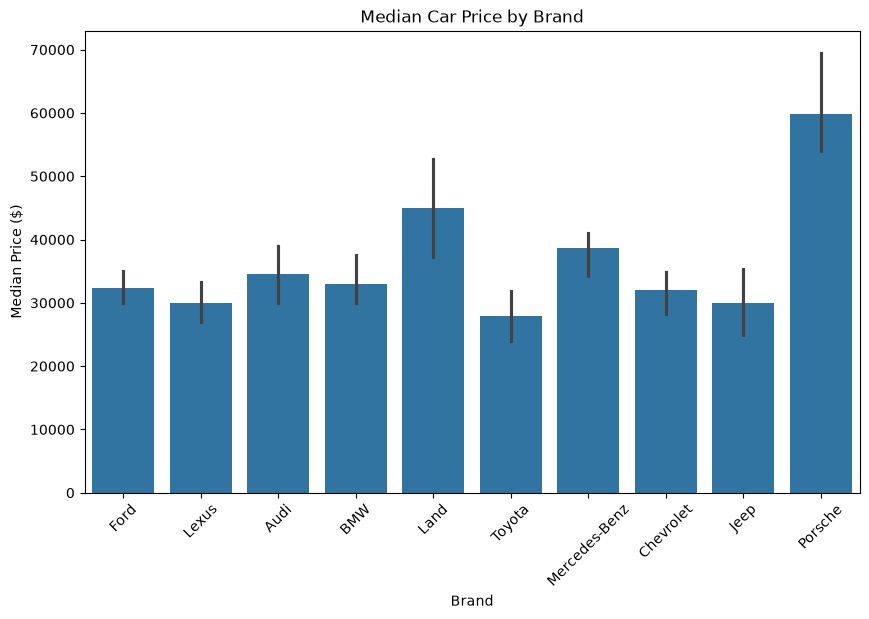

In [60]:
top_brands = df["brand"].value_counts().head(10).index

brand_data = df[df["brand"].isin(top_brands)]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=brand_data,
    x="brand",
    y="price",
    estimator="median"
)

plt.xticks(rotation=45)
plt.title("Median Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Price ($)")
plt.show()

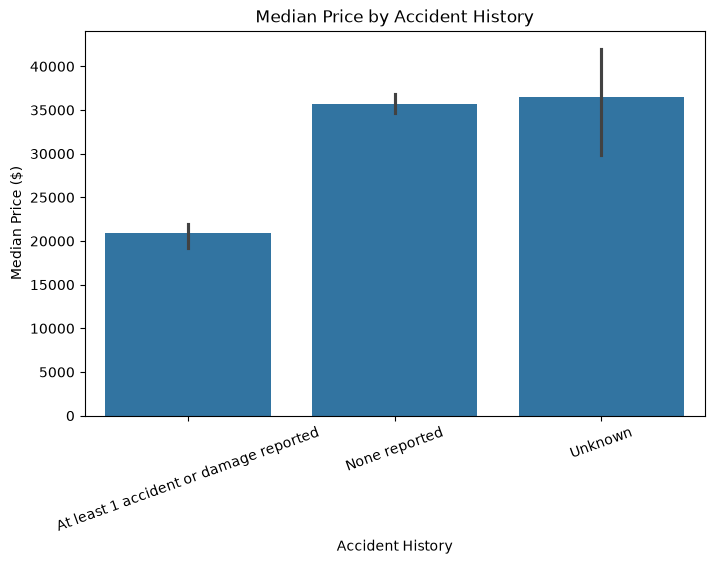

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="accident",
    y="price",
    estimator="median"
)

plt.xticks(rotation=20)
plt.title("Median Price by Accident History")
plt.xlabel("Accident History")
plt.ylabel("Median Price ($)")
plt.show()

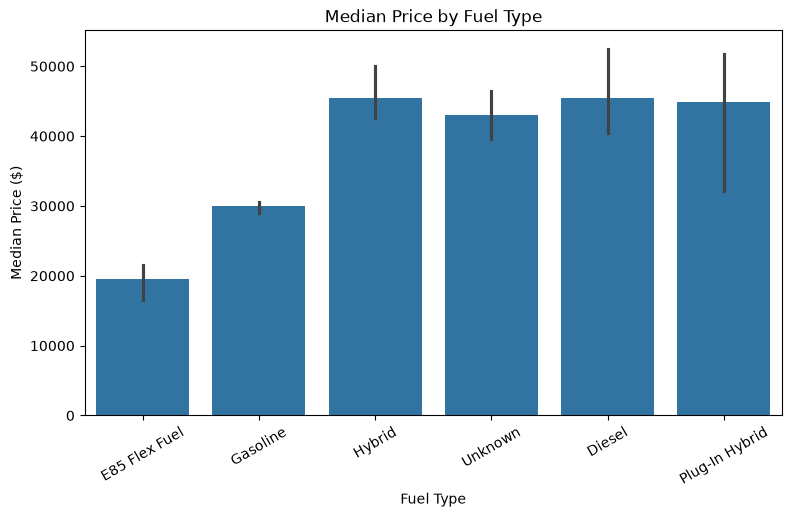

In [62]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="fuel_type",
    y="price",
    estimator="median"
)

plt.xticks(rotation=30)
plt.title("Median Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Median Price ($)")
plt.show()

### Categorical EDA Insights

- Brand shows a noticeable relationship with price. Porsche has the highest median price among the most common brands, while several mass-market brands have lower median prices.
- Cars with reported accident or damage history have a substantially lower median price than cars with no reported accidents.
- Fuel type is also associated with price. Hybrid, diesel, and plug-in hybrid vehicles generally have higher median prices than gasoline and E85 Flex Fuel vehicles.
- These results suggest that categorical features such as brand, accident history, and fuel type should be retained for model training.

## Feature Selection and Preprocessing

After completing exploratory data analysis, the next step is to prepare the dataset for machine learning.

The EDA showed that numerical features such as mileage, horsepower, engine size, and car age have meaningful relationships with price. Categorical features such as brand, fuel type, transmission, and accident history also appear useful for predicting car prices.

Some columns will not be used in the first version of the model:

- `model` has a very large number of unique categories.
- `model_year` contains the same information as the engineered `car_age` feature.
- `engine` is a raw text column, while useful numerical information has already been extracted into `horsepower` and `engine_size`.
- `ext_col` and `int_col` contain many unique categories and are not essential for the beginner version of the model.

The selected features will therefore be:

- Brand
- Mileage
- Fuel Type
- Transmission
- Accident History
- Horsepower
- Engine Size
- Car Age

The target variable is `price`.

Categorical features will need to be encoded into numerical form before they can be used by the machine learning models.

## Data Preprocessing

In [63]:
X = df[
    [
        "brand",
        "mileage",
        "fuel_type",
        "transmission",
        "accident",
        "horsepower",
        "engine_size",
        "car_age"
    ]
]

y = df["price"]

In [64]:
X.head()
X.dtypes

brand               str
mileage         float64
fuel_type           str
transmission        str
accident            str
horsepower      float64
engine_size     float64
car_age           int64
dtype: object

## Train-Test Split

Before training the machine learning models, the dataset is divided into training and testing sets.

The training set is used to teach the model the relationship between the selected features and the target price, while the testing set is kept separate and used to evaluate how well the trained model performs on unseen data.

For this project, 80% of the data is used for training and 20% is used for testing.

The split is performed before fitting any preprocessing steps such as encoding to reduce the risk of data leakage.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3206, 8)
X_test: (802, 8)
y_train: (3206,)
y_test: (802,)


## Categorical Feature Encoding

The dataset contains both numerical and categorical features. Machine learning models require numerical inputs, so categorical features such as brand, fuel type, transmission, and accident history need to be converted into numerical form.

One-Hot Encoding will be used to represent categorical values without creating an artificial order between categories.

A `ColumnTransformer` is used so that categorical features are encoded while numerical features remain unchanged.

In [67]:
categorical_features = [
    "brand",
    "fuel_type",
    "transmission",
    "accident"
]

numerical_features = [
    "mileage",
    "horsepower",
    "engine_size",
    "car_age"
]

In [68]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Baseline Model

Before training more advanced regression models, a simple baseline model is created.

The baseline gives us a reference point to compare against. If a machine learning model cannot perform better than this simple benchmark, then the model is not providing much value.

For this project, a `DummyRegressor` will be used with the mean strategy, which predicts the average training-set price for every car.

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','mileage','fuel_type',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [70]:
baseline_predictions = baseline_model.predict(X_test)
baseline_predictions[:10]

array([42749.55583281, 42749.55583281, 42749.55583281, 42749.55583281,
       42749.55583281, 42749.55583281, 42749.55583281, 42749.55583281,
       42749.55583281, 42749.55583281])

### Baseline Model Evaluation

The baseline model is evaluated using MAE, RMSE, and R².

- **MAE** measures the average absolute difference between actual and predicted prices.
- **RMSE** measures prediction error while penalizing larger mistakes more heavily.
- **R²** measures model performance compared with predicting the average target value.

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 31456.073096267442
Baseline RMSE: 98357.51721191136
Baseline R²: -0.003007423775014617


### Baseline Model Results

The mean-based Dummy Regressor predicted approximately the same price ($42,750) for every vehicle.

The baseline achieved:

- **MAE:** approximately $31,456
- **RMSE:** approximately $98,358
- **R²:** approximately -0.003

The R² score is close to zero, which is expected for a mean-based baseline model. The large difference between MAE and RMSE suggests that some high-priced luxury vehicles produce very large prediction errors.

These baseline results will be used as a reference when evaluating the actual regression models.

## Linear Regression Model

After establishing the baseline performance, a Linear Regression model is trained.

Unlike the Dummy Regressor, Linear Regression uses the input features to learn relationships between car characteristics and selling price.

The model is combined with the existing preprocessing steps using a Pipeline so that categorical encoding is applied consistently and only learned from the training data.

In [72]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [73]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','mileage','fuel_type',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [74]:
linear_predictions = linear_model.predict(X_test)
linear_predictions[:10]

array([  3279.01814086, -16737.35683672,  23343.86571647,  31426.23581226,
        86253.8892438 ,  59345.29552471,  34739.25506803,  89364.40754578,
         3396.95916961,   5183.07546044])

In [75]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 24106.823097674598
Linear Regression RMSE: 89415.06706825575
Linear Regression R²: 0.1710841468217119


In [76]:
print("Baseline MAE:", baseline_mae)
print("Linear MAE:", linear_mae)

print()

print("Baseline RMSE:", baseline_rmse)
print("Linear RMSE:", linear_rmse)

print()

print("Baseline R²:", baseline_r2)
print("Linear R²:", linear_r2)

Baseline MAE: 31456.073096267442
Linear MAE: 24106.823097674598

Baseline RMSE: 98357.51721191136
Linear RMSE: 89415.06706825575

Baseline R²: -0.003007423775014617
Linear R²: 0.1710841468217119


### Linear Regression Results

The Linear Regression model performed better than the baseline model across all three evaluation metrics.

- **MAE:** approximately $24,107, compared with $31,456 for the baseline.
- **RMSE:** approximately $89,415, compared with $98,358 for the baseline.
- **R²:** approximately 0.171, compared with approximately 0 for the baseline.

The lower MAE and RMSE indicate that Linear Regression produces more accurate predictions than simply predicting the average car price. The R² score shows that the model explains approximately 17.1% of the variation in car prices.

However, the RMSE remains considerably higher than the MAE, suggesting that some expensive vehicles still produce very large prediction errors. This indicates that the relationship between the selected features and car price may not be fully captured by a simple linear model.

## Decision Tree Regressor
A Decision Tree Regressor is used as the next model to capture nonlinear relationships between car features and price. Its performance will be compared with the baseline and Linear Regression models.

In [77]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

In [78]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','mileage','fuel_type',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [80]:
tree_predictions = tree_model.predict(X_test)
tree_predictions[:10]

array([16600., 11500., 42900., 25999., 68995., 61599., 30000., 59950.,
       13000.,  4000.])

In [82]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree MAE: 17239.85536159601
Decision Tree RMSE: 89580.96900767548
Decision Tree R²: 0.1680053295875562


In [83]:
print("Baseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

print("\nLinear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("\nDecision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Baseline
MAE: 31456.073096267442
RMSE: 98357.51721191136
R²: -0.003007423775014617

Linear Regression
MAE: 24106.823097674598
RMSE: 89415.06706825575
R²: 0.1710841468217119

Decision Tree
MAE: 17239.85536159601
RMSE: 89580.96900767548
R²: 0.1680053295875562


In [84]:
tree_train_predictions = tree_model.predict(X_train)

tree_train_mae = mean_absolute_error(
    y_train,
    tree_train_predictions
)

tree_train_r2 = r2_score(
    y_train,
    tree_train_predictions
)

print("Training MAE:", tree_train_mae)
print("Testing MAE:", tree_mae)

print("Training R²:", tree_train_r2)
print("Testing R²:", tree_r2)

Training MAE: 1.7155333749220212
Testing MAE: 17239.85536159601
Training R²: 0.9999991143493363
Testing R²: 0.1680053295875562


### Controlled Decision Tree

The initial Decision Tree achieved almost perfect training performance but much weaker test performance, indicating strong overfitting.

To reduce overfitting, the tree complexity is controlled using hyperparameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`. These settings restrict how deeply the tree can grow and prevent it from creating overly specific rules for individual training observations.

In [85]:
controlled_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

In [86]:
controlled_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','mileage','fuel_type',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [87]:
controlled_tree_predictions = controlled_tree_model.predict(X_test)

In [89]:
controlled_tree_mae = mean_absolute_error(
    y_test,
    controlled_tree_predictions
)

controlled_tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        controlled_tree_predictions
    )
)

controlled_tree_r2 = r2_score(
    y_test,
    controlled_tree_predictions
)

print("Controlled Tree MAE:", controlled_tree_mae)
print("Controlled Tree RMSE:", controlled_tree_rmse)
print("Controlled Tree R²:", controlled_tree_r2)

Controlled Tree MAE: 17760.278345227707
Controlled Tree RMSE: 87875.17431547005
Controlled Tree R²: 0.19938922369911616


In [90]:
controlled_train_predictions = controlled_tree_model.predict(X_train)

controlled_train_mae = mean_absolute_error(
    y_train,
    controlled_train_predictions
)

controlled_train_r2 = r2_score(
    y_train,
    controlled_train_predictions
)

print("Training MAE:", controlled_train_mae)
print("Testing MAE:", controlled_tree_mae)

print("Training R²:", controlled_train_r2)
print("Testing R²:", controlled_tree_r2)

Training MAE: 11063.312896914236
Testing MAE: 17760.278345227707
Training R²: 0.7918856701856221
Testing R²: 0.19938922369911616


### Controlled Decision Tree Results

The unrestricted Decision Tree showed strong overfitting, achieving almost perfect performance on the training data but much weaker performance on the test set.

To reduce overfitting, the tree was constrained using `max_depth`, `min_samples_split`, and `min_samples_leaf`.

The controlled Decision Tree achieved:

- **Training MAE:** approximately $11,063
- **Testing MAE:** approximately $17,760
- **Training R²:** approximately 0.792
- **Testing R²:** approximately 0.199
- **Testing RMSE:** approximately $87,875

Compared with the unrestricted tree, the controlled model has weaker training performance but improved test RMSE and R². This suggests that limiting tree complexity reduced overfitting and improved generalization.

The slight increase in MAE shows that no single metric should be used alone when comparing regression models.

## Random Forest Regressor

A Random Forest Regressor combines the predictions of multiple Decision Trees.

Instead of relying on a single tree, the model trains many trees using different samples and subsets of features, then averages their predictions.

This generally improves stability and reduces the overfitting seen in individual Decision Trees.

In [92]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

In [93]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','mileage','fuel_type',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [95]:
rf_predictions = random_forest_model.predict(
    X_test
)

rf_predictions[:10]


array([11275.55674536, 12277.5408907 , 27807.7397874 , 24203.57394854,
       45478.62287814, 51990.19433382, 39382.07493008, 79295.35496665,
       14606.24229253, 10408.28908444])

In [97]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 15419.23603261336
Random Forest RMSE: 82367.52059256617
Random Forest R²: 0.2966021788551072


In [98]:
rf_train_predictions = random_forest_model.predict(
    X_train
)

rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

print("Training MAE:", rf_train_mae)
print("Testing MAE:", rf_mae)

print("Training R²:", rf_train_r2)
print("Testing R²:", rf_r2)

Training MAE: 9948.044189198923
Testing MAE: 15419.23603261336
Training R²: 0.7964882964158988
Testing R²: 0.2966021788551072


## Final Model Comparison

Four regression approaches were evaluated using MAE, RMSE, and R².

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline | $31,456 | $98,358 | -0.003 |
| Linear Regression | $24,107 | $89,415 | 0.171 |
| Controlled Decision Tree | $17,760 | $87,875 | 0.199 |
| Random Forest | $15,419 | $82,368 | 0.297 |

The Random Forest Regressor achieved the best overall performance, with the lowest MAE and RMSE and the highest R² score.

Compared with the baseline, Random Forest reduced the average absolute prediction error from approximately $31,456 to $15,419.

The improvement suggests that combining multiple Decision Trees allows the model to capture nonlinear relationships between vehicle features and price more effectively than Linear Regression or a single Decision Tree.

Although Random Forest performed best, the difference between training and testing performance still indicates some remaining overfitting. In addition, the relatively modest R² score suggests that important factors affecting used-car prices may not be fully represented by the selected features.

## Feature Importance

Feature importance is used to understand which input features contributed most to the Random Forest model's predictions.

Because categorical variables were one-hot encoded during preprocessing, the model works with the transformed feature names rather than only the original columns.

The feature importance scores help identify which variables had the greatest influence on predicted car prices.

In [102]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance values from Random Forest
importances = random_forest_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
120,remainder__mileage,0.411241
122,remainder__engine_size,0.205293
24,categorical__brand_Lamborghini,0.135056
121,remainder__horsepower,0.100059
45,categorical__brand_Rolls-Royce,0.046861
123,remainder__car_age,0.042632
42,categorical__brand_Porsche,0.024041
84,categorical__transmission_7-Speed Automatic wi...,0.010535
35,categorical__brand_Mercedes-Benz,0.004919
12,categorical__brand_Ferrari,0.004583


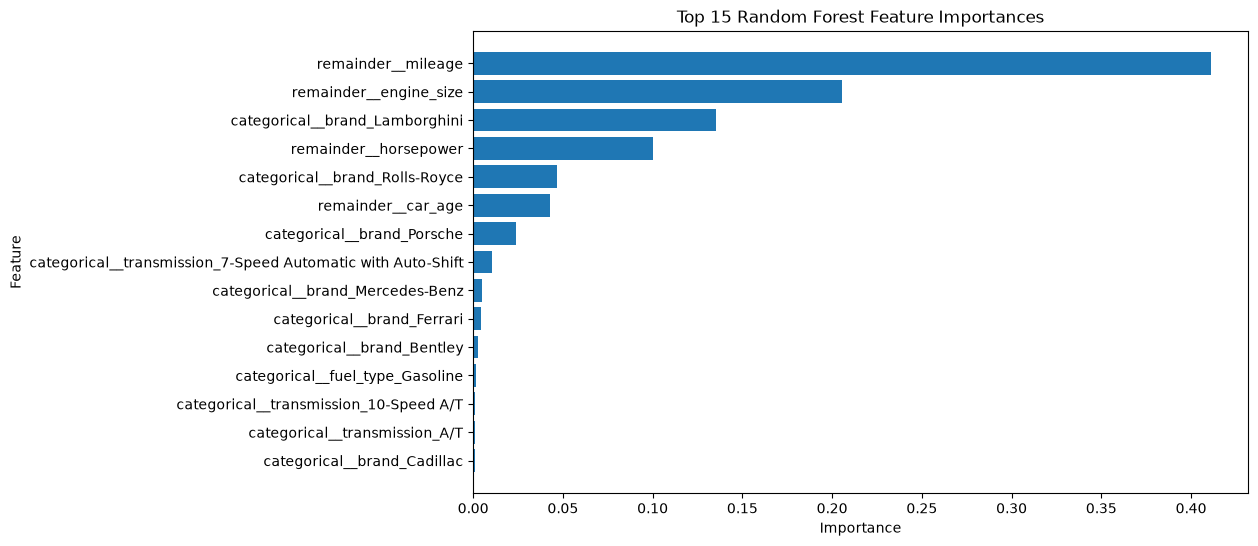

In [104]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

### Feature Importance Insights

- Mileage is the most important feature used by the Random Forest model.
- Engine size and horsepower also contribute strongly to price prediction.
- Luxury brands such as Lamborghini, Rolls-Royce, and Porsche have relatively high importance because their prices differ significantly from the average vehicle.
- Car age also contributes to prediction, although its importance is lower than mileage and engine-related features.
- Feature importance shows how strongly the model relied on each feature, but it does not indicate whether the relationship with price is positive or negative.

In [105]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_predictions
})

In [106]:
comparison_df.head(10)

,Actual Price,Predicted Price
0,12900.0,11275.556745
1,5900.0,12277.540891
2,40500.0,27807.739787
3,29995.0,24203.573949
4,79990.0,45478.622878
5,44900.0,51990.194334
6,36000.0,39382.074930
7,47214.0,79295.354967
8,13599.0,14606.242293
9,11000.0,10408.289084


In [109]:
comparison_df["Error"] = (
    comparison_df["Actual Price"]
    - comparison_df["Predicted Price"]
)

comparison_df["Absolute Error"] = (
    comparison_df["Error"].abs()
)

comparison_df.head(10)

,Actual Price,Predicted Price,Error,Absolute Error
0,12900.0,11275.556745,1624.443255,1624.443255
1,5900.0,12277.540891,-6377.540891,6377.540891
2,40500.0,27807.739787,12692.260213,12692.260213
3,29995.0,24203.573949,5791.426051,5791.426051
4,79990.0,45478.622878,34511.377122,34511.377122
5,44900.0,51990.194334,-7090.194334,7090.194334
6,36000.0,39382.074930,-3382.074930,3382.074930
7,47214.0,79295.354967,-32081.354967,32081.354967
8,13599.0,14606.242293,-1007.242293,1007.242293
9,11000.0,10408.289084,591.710916,591.710916


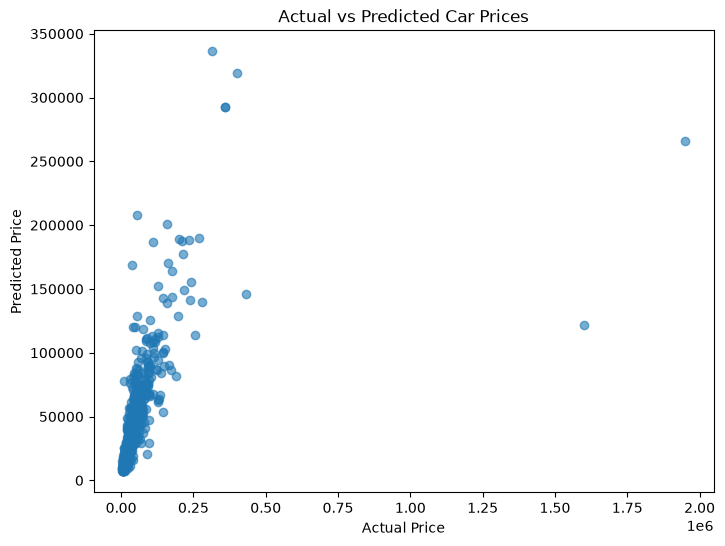

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual Price"],
    comparison_df["Predicted Price"],
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

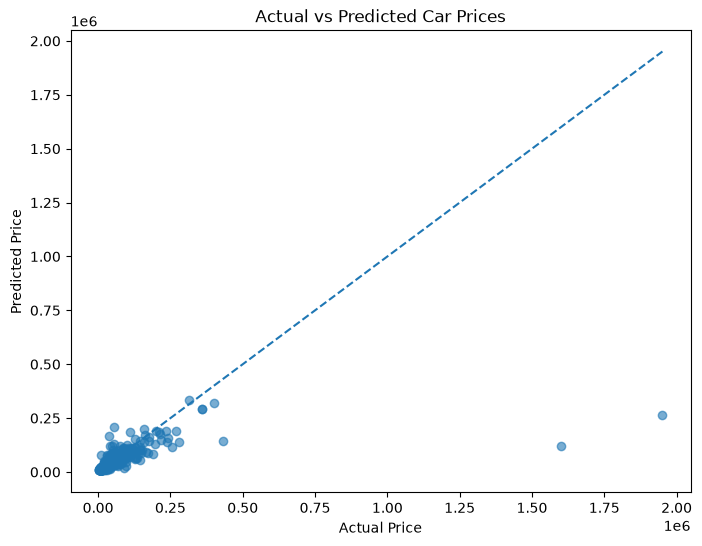

In [114]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual Price"],
    comparison_df["Predicted Price"],
    alpha=0.6
)

min_price = min(
    comparison_df["Actual Price"].min(),
    comparison_df["Predicted Price"].min()
)

max_price = max(
    comparison_df["Actual Price"].max(),
    comparison_df["Predicted Price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Actual vs Predicted Price Analysis

The actual and predicted car prices were compared to evaluate how closely the Random Forest model estimates unseen vehicle prices.

Points closer to the diagonal reference line represent more accurate predictions, while points farther away indicate larger prediction errors.

The visualization helps identify whether the model performs consistently across different price ranges and whether expensive vehicles are more difficult to predict.

### Actual vs Predicted Price Insights

The Random Forest predictions are relatively close to the actual prices for most vehicles in the normal price range.

However, the model substantially underestimates several extremely expensive luxury vehicles. These large prediction errors explain why RMSE remains considerably higher than MAE.

This suggests that the model performs better for common used cars than for rare, high-value vehicles that are underrepresented in the dataset.

In [115]:
error_analysis = X_test.copy()

error_analysis["Actual Price"] = y_test
error_analysis["Predicted Price"] = rf_predictions

error_analysis["Absolute Error"] = abs(
    error_analysis["Actual Price"]
    - error_analysis["Predicted Price"]
)

error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

,brand,mileage,fuel_type,transmission,accident,horsepower,engine_size,car_age,Actual Price,Predicted Price,Absolute Error
229,Bugatti,6330.0,Gasoline,7-Speed Automatic with Auto-Shift,None reported,310.0,8.0,13,1950995.0,266258.758503,1.684736e+06
3045,Porsche,4400.0,Gasoline,6-Speed M/T,None reported,605.0,5.7,19,1599000.0,121354.467156,1.477646e+06
203,Ford,1897.0,Gasoline,Manual,None reported,310.0,5.4,19,429998.0,145967.369913,2.840306e+05
222,Dodge,1240.0,Gasoline,8-Speed Automatic,None reported,310.0,6.4,2,53900.0,207837.623084,1.539376e+05
1572,Ferrari,14770.0,Gasoline,7-Speed Automatic with Auto-Shift,None reported,310.0,6.3,8,254900.0,113786.387864,1.411136e+05
93,Aston,2165.0,Gasoline,8-Speed Automatic,None reported,310.0,5.2,3,279950.0,139722.221885,1.402278e+05
3859,Chevrolet,500.0,Gasoline,6-Speed A/T,At least 1 accident or damage reported,355.0,5.3,9,37000.0,169094.916494,1.320949e+05
2428,Bentley,33000.0,Gasoline,A/T,None reported,542.0,4.0,4,188500.0,81621.148198,1.068789e+05
1003,Maserati,1220.0,Gasoline,"Automatic, 8-Spd Dual-Clutch",None reported,310.0,3.0,2,238900.0,141211.296851,9.768870e+04
2392,Acura,6523.0,Hybrid,9-Speed Automatic with Auto-Shift,None reported,310.0,3.5,6,143900.0,53762.830863,9.013717e+04


### Error Analysis

The largest prediction errors were mainly observed for rare and high-value vehicles such as Bugatti, Porsche, Ferrari, Aston Martin, Bentley, and Maserati.

The two largest errors occurred for vehicles priced at approximately $1.95 million and $1.60 million, which the model substantially underestimated. These extreme errors contribute heavily to the relatively high RMSE.

Several factors may explain these errors:

- Rare luxury and collector vehicles are underrepresented in the dataset.
- The exact vehicle `model` was excluded because of its very high cardinality, meaning the model cannot distinguish between ordinary and rare models within the same brand.
- Some horsepower values were unavailable in the original engine descriptions and were replaced with the median value, which may reduce accuracy for high-performance vehicles.
- Used-car prices can also depend on factors not represented in the selected features, such as trim, condition, rarity, service history, and market demand.

Overall, the model performs more reliably for common used vehicles than for rare or extremely high-priced cars.

In [116]:
error_analysis["Price Range"] = pd.cut(
    error_analysis["Actual Price"],
    bins=[0, 50000, 100000, 250000, float("inf")],
    labels=[
        "Under $50k",
        "$50k-$100k",
        "$100k-$250k",
        "Above $250k"
    ]
)

In [117]:
price_range_errors = (
    error_analysis
    .groupby("Price Range", observed=True)["Absolute Error"]
    .mean()
)

price_range_errors

Price Range
Under $50k       6786.656642
$50k-$100k      16458.505962
$100k-$250k     41213.456841
Above $250k    404498.232940
Name: Absolute Error, dtype: float64

### Prediction Error by Price Range

The model's prediction accuracy varies significantly across different vehicle price ranges.

- Cars priced below $50,000 have an average absolute error of approximately $6,787.
- Cars between $50,000 and $100,000 have an average error of approximately $16,459.
- Cars between $100,000 and $250,000 have an average error of approximately $41,213.
- Cars priced above $250,000 have a much larger average error of approximately $404,498.

This indicates that the Random Forest model performs considerably better on common, lower-priced vehicles than on rare and extremely expensive vehicles.

The high error for luxury and collector vehicles is likely influenced by their limited representation in the dataset and by missing detailed information such as exact vehicle model, trim, rarity, and condition.

## Final Model Conclusion

Several regression models were trained and compared using MAE, RMSE, and R².

The Random Forest Regressor achieved the best overall test performance among the evaluated models:

- **MAE:** approximately $15,419
- **RMSE:** approximately $82,368
- **R²:** approximately 0.297

Compared with the baseline model, Random Forest substantially reduced the average prediction error and explained a larger proportion of the variation in used-car prices.

Feature importance analysis showed that mileage, engine size, horsepower, car age, and several luxury-brand indicators were among the most influential features.

Error analysis showed that the model performs considerably better for common used vehicles than for rare and extremely expensive cars. Vehicles below $50,000 had an average absolute prediction error of approximately $6,787, while vehicles above $250,000 had much larger errors.

Based on the current results, Random Forest is selected as the best-performing model for this project.

## Model Limitations

Although the Random Forest model performed better than the other evaluated models, several limitations remain:

- Rare luxury and collector vehicles are underrepresented in the dataset, making their prices difficult to predict accurately.
- The exact `model` feature was excluded because it contains a very large number of unique categories. This reduces the model's ability to distinguish between ordinary and rare vehicles within the same brand.
- Some horsepower and engine-size values were unavailable in the original engine descriptions and had to be imputed, which may reduce prediction accuracy.
- Used-car prices can depend on additional factors not represented in the dataset, such as vehicle condition, trim level, service history, modifications, rarity, seller behavior, location, and current market demand.
- The model still shows a difference between training and testing performance, indicating some remaining overfitting.
- Prediction accuracy decreases significantly for very expensive vehicles.

## Final Model Improvement Experiment

The current Random Forest model performs best among the evaluated models, but error analysis shows that rare and high-value vehicles remain difficult to predict.

One possible reason is that the exact vehicle `model` was excluded because of its high cardinality. To test whether this information improves prediction performance, a second Random Forest model will be trained with the `model` feature included.

The improved model will be compared with the existing Random Forest using MAE, RMSE, and R².

In [118]:
X_improved = df[
    [
        "brand",
        "model",
        "mileage",
        "fuel_type",
        "transmission",
        "accident",
        "horsepower",
        "engine_size",
        "car_age"
    ]
]

y_improved = df["price"]

In [119]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.2,
    random_state=42
)

In [120]:
categorical_features_imp = [
    "brand",
    "model",
    "fuel_type",
    "transmission",
    "accident"
]

In [121]:
numerical_features_imp = [
    "mileage",
    "horsepower",
    "engine_size",
    "car_age"
]

In [122]:
preprocessor_imp = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_imp
        )
    ],
    remainder="passthrough"
)

In [123]:
improved_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_imp),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

In [124]:
improved_rf_model.fit(
    X_train_imp,
    y_train_imp
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['brand','model','mileage',...,'horsepower','engine_size','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concaten

In [125]:
improved_rf_predictions = improved_rf_model.predict(
    X_test_imp
)

In [127]:
improved_rf_mae = mean_absolute_error(
    y_test_imp,
    improved_rf_predictions
)

improved_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_imp,
        improved_rf_predictions
    )
)

improved_rf_r2 = r2_score(
    y_test_imp,
    improved_rf_predictions
)

print("Improved Random Forest MAE:", improved_rf_mae)
print("Improved Random Forest RMSE:", improved_rf_rmse)
print("Improved Random Forest R²:", improved_rf_r2)

Improved Random Forest MAE: 15403.941139599156
Improved Random Forest RMSE: 82357.30673062493
Improved Random Forest R²: 0.2967766156412903
